## Импорты

In [1]:
!pip install imblearn
!pip install lightgbm
!pip install xgboost
!pip install catboost


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import itertools
import warnings

from sklearn.utils.class_weight import compute_class_weight
warnings.filterwarnings('ignore')


In [3]:
"""
Предварительный анализ данных

"""

def total_analyse(data):
    print(f"Общая информация:\n")
    print(data.info())
    print('-'*30)
    
    print(f"\nСодержание таблицы:\n")
    print(data.head(5))
    print('-'*30)
    
    print(f"\nСтатистика\n")
    num_cols=[]
    for column in data.columns:
        if data[column].dtype in ['int64', 'float64', 'int32', 'float32', 'int', 'float']:
            num_cols.append(column)
    if num_cols:
        print(data[num_cols].describe())
    print('-'*30)

    print(f"\nПропущенные значения:\n")
    print(data.isnull().sum().sort_values(ascending=False))
    print('-'*30)


## Загрузка данных

In [4]:
train = pd.read_csv('train_apps.csv')
test = pd.read_csv('test_apps.csv')

## Первичный анализ

In [5]:
total_analyse(train)

Общая информация:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145241 entries, 0 to 145240
Data columns (total 28 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   front_id                           145241 non-null  int64  
 1   decision_day                       145241 non-null  object 
 2   loan_amount_last                   145241 non-null  float64
 3   overdraft_limit_min                145241 non-null  float64
 4   overdraft_limit_max                145241 non-null  float64
 5   offered_rate                       145241 non-null  float64
 6   cb_rate                            145241 non-null  float64
 7   corp_credit_products               94053 non-null   float64
 8   sum_deb_ul_90                      91130 non-null   float64
 9   sum_deb_ul_30                      83788 non-null   float64
 10  cnt_deb_loan_90                    113783 non-null  float64
 11  cnt_deb_ul_ip_90    

In [6]:
total_analyse(test)

Общая информация:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36311 entries, 0 to 36310
Data columns (total 27 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   front_id                           36311 non-null  int64  
 1   decision_day                       36311 non-null  object 
 2   loan_amount_last                   36311 non-null  float64
 3   overdraft_limit_min                36311 non-null  float64
 4   overdraft_limit_max                36311 non-null  float64
 5   offered_rate                       36311 non-null  float64
 6   cb_rate                            36311 non-null  float64
 7   corp_credit_products               28709 non-null  float64
 8   sum_deb_ul_90                      27707 non-null  float64
 9   sum_deb_ul_30                      25906 non-null  float64
 10  cnt_deb_loan_90                    32230 non-null  float64
 11  cnt_deb_ul_ip_90                   

In [7]:
def prepare_data(train, test):
    """Pipeline подготовки данных"""
    
    # 1. Копируем данные
    train_processed = train.copy()
    test_processed = test.copy()
    
    # 2. Удаляем признаки с >90% пропусков
    cols_to_drop = [
        'overdraft_app_term_max_360',
        'loan_rev_max_start_non_fin', 
        'loan_rev_min_start_fin',
        'sum_deb_investment_90'
    ]
    
    train_processed = train_processed.drop(columns=cols_to_drop, errors='ignore')
    test_processed = test_processed.drop(columns=cols_to_drop, errors='ignore')
    
    # 3. Создаем флаги пропусков для важных признаков
    flag_features = [
        'days_from_authperson_registration',
        'sum_deb_ul_30',
        'db_group_last',
        'app_term_mean_360',
        'sum_deb_ul_90',
        'balance_rur_amt_30_min'
    ]
    
    for col in flag_features:
        if col in train_processed.columns:
            train_processed[f'{col}_missing'] = train_processed[col].isnull().astype(int)
            test_processed[f'{col}_missing'] = test_processed[col].isnull().astype(int)
    
    # 4. Импутация числовых признаков медианой
    numeric_cols = train_processed.select_dtypes(include=['float64', 'int64']).columns
    numeric_cols = [col for col in numeric_cols if col not in ['front_id', 'target_value']]
    
    for col in numeric_cols:
        median_val = train_processed[col].median()
        train_processed[col] = train_processed[col].fillna(median_val)
        test_processed[col] = test_processed[col].fillna(median_val)
    
    # 5. Импутация категориальных признаков
    cat_cols = ['db_group_last', 'fl_adminarea']
    for col in cat_cols:
        if col in train_processed.columns:
            mode_val = train_processed[col].mode()
            if len(mode_val) > 0:
                train_processed[col] = train_processed[col].fillna(mode_val[0])
                test_processed[col] = test_processed[col].fillna(mode_val[0])
            else:
                train_processed[col] = train_processed[col].fillna('unknown')
                test_processed[col] = test_processed[col].fillna('unknown')
    
    return train_processed, test_processed

# Применяем
train_clean, test_clean = prepare_data(train, test)

# Проверяем пропуски после обработки
print("Пропуски после обработки в train:")
print(train_clean.isnull().sum().sum())  
print(test_clean.isnull().sum().sum())

Пропуски после обработки в train:
0
0


In [8]:
def handle_rate_outliers(df):

#Обрезаем выбросы
    upper = df['offered_rate'].quantile(0.99)
    lower = df['offered_rate'].quantile(0.01)
    df['offered_rate'] = df['offered_rate'].clip(lower, upper)
    return df  

# Применяем
train_clean = handle_rate_outliers(train_clean)
test_clean = handle_rate_outliers(test_clean)

## Баланс классов

 Распределение целевой переменной 
Согласились (1): 8,846 (6.09%)
Отказались (0): 136,395 (93.91%)
Дисбаланс: 15.42:1


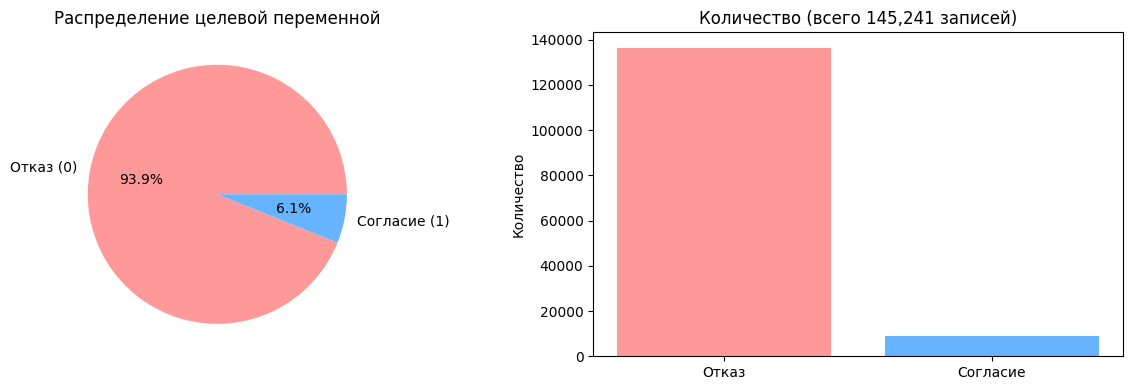

In [9]:
target_dist = train['target_value'].value_counts()
target_pct = train['target_value'].value_counts(normalize=True) * 100

print(" Распределение целевой переменной ")
print(f"Согласились (1): {target_dist[1]:,} ({target_pct[1]:.2f}%)")
print(f"Отказались (0): {target_dist[0]:,} ({target_pct[0]:.2f}%)")
print(f"Дисбаланс: {target_dist[0]/target_dist[1]:.2f}:1")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].pie(target_dist, labels=['Отказ (0)', 'Согласие (1)'], 
            autopct='%1.1f%%', colors=['#ff9999', '#66b3ff'])
axes[0].set_title('Распределение целевой переменной')

axes[1].bar(['Отказ', 'Согласие'], target_dist.values, color=['#ff9999', '#66b3ff'])
axes[1].set_title(f'Количество (всего {len(train):,} записей)')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

## Анализ параметров кредитного предложения

## Корр анализ

 Корреляция признаков с target_value 
                         feature  correlation
                cnt_cred_loan_90     0.213963
                 cnt_deb_loan_90     0.189984
                cnt_deb_ul_ip_90     0.118274
                cnt_deb_ul_ip_30     0.117245
             overdraft_limit_max     0.111680
             overdraft_limit_min     0.109427
                         cb_rate     0.107699
 count_all_corp_dashboard_events     0.098831
                   sum_deb_ul_90     0.097233
                   sum_deb_ul_30     0.086907
          p75_time_spent_minutes     0.086006
            corp_credit_products     0.074201
                       corp_list     0.048517
fl_hdb_bki_total_active_products    -0.010273
                    offered_rate    -0.025672
                loan_amount_last    -0.043482
          balance_rur_amt_30_min    -0.067370
               app_term_mean_360    -0.101623


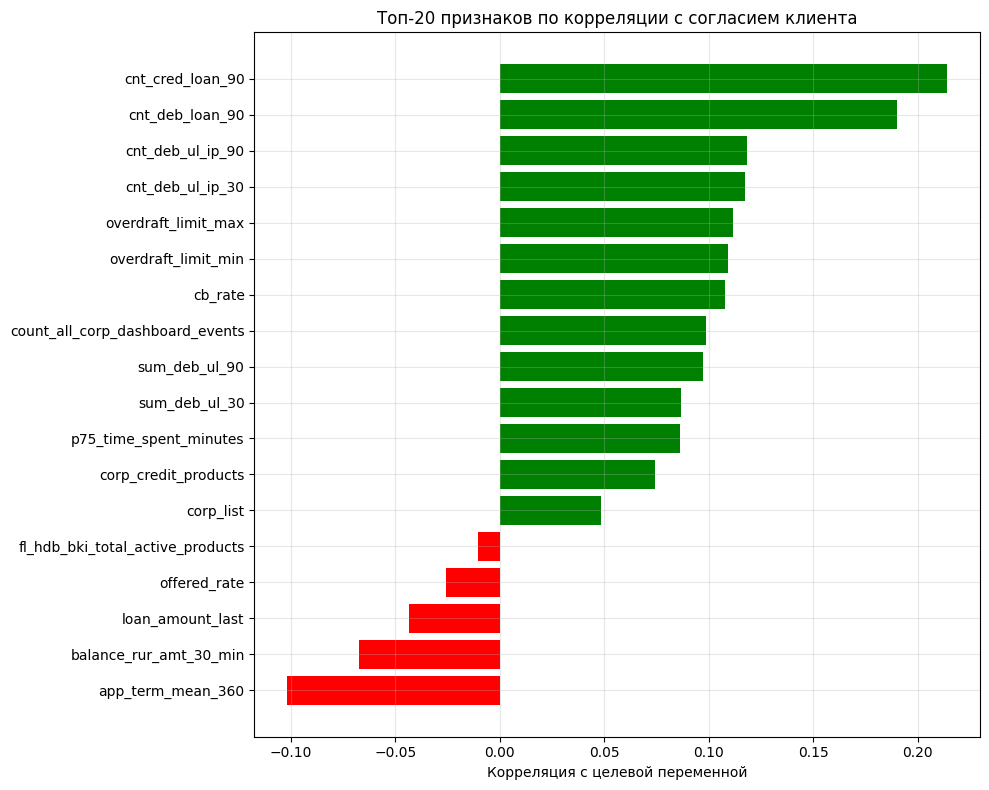

In [10]:
# Выбираем числовые признаки с нормальным количеством пропусков
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns
numeric_cols = [col for col in numeric_cols if col not in ['front_id', 'target_value'] 
                and train[col].isnull().mean() < 0.5]  # берем признаки с <50% пропусков

# Корреляция с целевой переменной
correlations = []
for col in numeric_cols:
    # Заполняем пропуски медианой для корреляции
    data = train[col].fillna(train[col].median())
    corr = data.corr(train['target_value'])
    correlations.append({'feature': col, 'correlation': corr})

corr_df = pd.DataFrame(correlations).sort_values('correlation', ascending=False)

print(" Корреляция признаков с target_value ")
print(corr_df.to_string(index=False))

# Визуализация топ-20 корреляций
plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in corr_df['correlation'].values[:20]]
plt.barh(corr_df['feature'][:20], corr_df['correlation'][:20], color=colors)
plt.xlabel('Корреляция с целевой переменной')
plt.title('Топ-20 признаков по корреляции с согласием клиента')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Борьба с дисбалансом классов (15.4:1)

In [11]:
class_weights = compute_class_weight('balanced', classes=np.unique(train['target_value']), 
                                      y=train['target_value'])
weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Weights: {weight_dict}")


Weights: {0: 0.5324278749221012, 1: 8.209416685507573}


## Подготовка данных, обучение, тестирование

In [13]:

# 1. СОЗДАНИЕ ДОПОЛНИТЕЛЬНЫХ ПРИЗНАКОВ


def create_features(df):
    df_new = df.copy()
    
    # 1. Отношение запрошенного лимита к максимальному
    df_new['limit_ratio'] = df_new['loan_amount_last'] / (df_new['overdraft_limit_max'] + 1e-5)
    
    # 2. Спред между ставкой и ключевой ставкой ЦБ
    df_new['rate_spread'] = df_new['offered_rate'] - df_new['cb_rate']
    
    # 3. Готовность банка дать больше, чем просит клиент
    df_new['bank_willingness'] = df_new['overdraft_limit_max'] - df_new['loan_amount_last']
    
    # 4. Платежеспособность (остаток на счете / запрошенная сумма)
    df_new['solvency'] = df_new['balance_rur_amt_30_min'].fillna(0) / (df_new['loan_amount_last'].abs() + 1e-5)
    
    # 5. Кредитная активность (сумма кредитов и займов)
    df_new['credit_activity'] = df_new['cnt_cred_loan_90'].fillna(0) + df_new['cnt_deb_loan_90'].fillna(0)
    
    return df_new

# Применяем к очищенным данным
train_model = create_features(train_clean)
test_model = create_features(test_clean)

print(f"   Добавлено признаков: 5")
print(f"   Всего признаков: {train_model.shape[1]}")


# 2. КОДИРОВАНИЕ КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ


cat_cols = ['db_group_last', 'fl_adminarea']
encoders = {}

for col in cat_cols:
    if col in train_model.columns:
        all_vals = pd.concat([train_model[col], test_model[col]]).fillna('unknown').astype(str).unique()
        le = LabelEncoder()
        le.fit(all_vals)
        train_model[col] = le.transform(train_model[col].fillna('unknown').astype(str))
        test_model[col] = le.transform(test_model[col].fillna('unknown').astype(str))
        encoders[col] = le
        print(f"   {col}: {len(le.classes_)} категорий")


# 3. ОПРЕДЕЛЕНИЕ ПРИЗНАКОВ

exclude_cols = ['front_id', 'decision_day', 'target_value']
feature_cols = [col for col in train_model.columns if col not in exclude_cols]

X = train_model[feature_cols]
y = train_model['target_value']
groups = train_model['front_id']

print(f"   Признаков: {len(feature_cols)}")
print(f"   Уникальных заявок: {groups.nunique()}")
print(f"   Офферов на заявку: {len(groups)/groups.nunique():.2f}")


# 4. РАСЧЕТ ВЕСА ДЛЯ ДИСБАЛАНСА КЛАССОВ


scale_pos_weight = len(y[y==0]) / len(y[y==1])
print(f"   scale_pos_weight = {scale_pos_weight:.2f}")


# 5. ПОИСК ЛУЧШИХ ПАРАМЕТРОВ (5 КОМБИНАЦИЙ)


# Фиксированные параметры
fixed_params = {
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.05,
    'reg_lambda': 0.05,
    'min_child_samples': 30,
    'scale_pos_weight': scale_pos_weight,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}


combinations = [
    
    (600, 0.015, 27, 8),   # средние параметры
    (800, 0.020, 31, 7),   # базовые 
    (700, 0.018, 29, 8),   # между средними
    (600, 0.020, 31, 7),   # больше lr, больше leaves
    (800, 0.015, 27, 8),   # больше деревьев, меньше lr
]

print(f"   Всего комбинаций: {len(combinations)}")
print(f"   Оценка: 3 фолда GroupKFold")

def evaluate_params(params, n_folds=3):
    model = lgb.LGBMClassifier(**params)
    gkf = GroupKFold(n_splits=n_folds)
    cv_scores = []
    
    for train_idx, val_idx in gkf.split(X, y, groups=groups):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        y_pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        cv_scores.append(auc)
    
    return np.mean(cv_scores), np.std(cv_scores)

best_score = 0
best_params = {}
results = []

print("\n   Поиск...")
for i, combo in enumerate(combinations):
    params = {
        'n_estimators': combo[0],
        'learning_rate': combo[1],
        'num_leaves': combo[2],
        'max_depth': combo[3],
        **fixed_params
    }
    
    mean_auc, std_auc = evaluate_params(params, n_folds=3)
    results.append({
        'n_estimators': combo[0],
        'learning_rate': combo[1],
        'num_leaves': combo[2],
        'max_depth': combo[3],
        'auc': mean_auc,
        'std': std_auc
    })
    
    print(f"   [{i+1}/{len(combinations)}] n={combo[0]}, lr={combo[1]:.3f}, leaves={combo[2]}, depth={combo[3]} → AUC={mean_auc:.4f} (±{std_auc:.4f})")
    
    if mean_auc > best_score:
        best_score = mean_auc
        best_params = params
        print(f"      >>> НОВЫЙ ЛУЧШИЙ! AUC={best_score:.4f}")


# 6. ВЫВОД ЛУЧШИХ ПАРАМЕТРОВ


print("\n" + "="*80)
print("6. ЛУЧШИЕ ПАРАМЕТРЫ")
print("="*80)

results_df = pd.DataFrame(results).sort_values('auc', ascending=False)

print("\n   Все комбинации (от лучшей к худшей):")
print(results_df.to_string(index=False))

print(f"\n   ЛУЧШИЙ AUC: {best_score:.4f}")
print(f"   ЛУЧШИЕ ПАРАМЕТРЫ:")
for k, v in best_params.items():
    print(f"      {k}: {v}")


# 7. ФИНАЛЬНАЯ ПРОВЕРКА (5 ФОЛДОВ)


def evaluate_final(params):
    gkf = GroupKFold(n_splits=5)
    cv_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**params)
        model.fit(X_tr, y_tr)
        y_pred = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_pred)
        cv_scores.append(auc)
        print(f"   Fold {fold+1}: AUC = {auc:.4f}")
    
    return np.mean(cv_scores), np.std(cv_scores)

final_auc, final_std = evaluate_final(best_params)

print(f"\n   Финальный GroupKFold AUC (5 фолдов): {final_auc:.4f} (+/- {final_std:.4f})")


# 8. ОБУЧЕНИЕ ФИНАЛЬНОЙ МОДЕЛИ НА ВСЕХ ДАННЫХ


final_model = lgb.LGBMClassifier(**best_params)
final_model.fit(X, y)


# 9. ПРЕДСКАЗАНИЕ НА ТЕСТОВОЙ ВЫБОРКЕ

X_test = test_model[feature_cols]
test_pred = final_model.predict_proba(X_test)[:, 1]

print(f"   Предсказания: min={test_pred.min():.4f}, max={test_pred.max():.4f}, mean={test_pred.mean():.4f}")
print(f"   Доля согласий в train: {y.mean():.4f}")


# 10. СОХРАНЕНИЕ РЕЗУЛЬТАТА


submission = pd.DataFrame({
    'front_id': test_model['front_id'],
    'target_value': test_pred
})

submission.to_csv('submission_full_features_groupkfold.csv', index=False)
print(f"\n   submission_full_features_groupkfold.csv сохранен")


# 11. ВАЖНОСТЬ ПРИЗНАКОВ


importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n   Топ-15 важных признаков:")
for i, row in importance_df.head(15).iterrows():
    print(f"      {row['feature']}: {row['importance']:.0f}")

# 12. ИТОГИ


print("\n" + "="*80)
print("ИТОГИ")
print("="*80)
print(f"""
   GroupKFold CV AUC: {final_auc:.4f} (+/- {final_std:.4f})
  
    Лучшие параметры (найдены через Grid Search):
     • n_estimators: {best_params['n_estimators']}
     • learning_rate: {best_params['learning_rate']:.4f}
     • num_leaves: {best_params['num_leaves']}
     • max_depth: {best_params['max_depth']}
     • subsample: {best_params['subsample']}
     • colsample_bytree: {best_params['colsample_bytree']}
     • reg_alpha: {best_params['reg_alpha']}
     • reg_lambda: {best_params['reg_lambda']}
     • min_child_samples: {best_params['min_child_samples']}
     • scale_pos_weight: {best_params['scale_pos_weight']:.2f}
  
   Файл: submission_full_features_groupkfold.csv
""")

print("="*80)

   Добавлено признаков: 5
   Всего признаков: 35
   db_group_last: 9 категорий
   fl_adminarea: 83 категорий
   Признаков: 32
   Уникальных заявок: 145241
   Офферов на заявку: 1.00
   scale_pos_weight = 15.42
   Всего комбинаций: 5
   Оценка: 3 фолда GroupKFold

   Поиск...
   [1/5] n=600, lr=0.015, leaves=27, depth=8 → AUC=0.8208 (±0.0054)
      >>> НОВЫЙ ЛУЧШИЙ! AUC=0.8208
   [2/5] n=800, lr=0.020, leaves=31, depth=7 → AUC=0.8182 (±0.0058)
   [3/5] n=700, lr=0.018, leaves=29, depth=8 → AUC=0.8193 (±0.0055)
   [4/5] n=600, lr=0.020, leaves=31, depth=7 → AUC=0.8193 (±0.0059)
   [5/5] n=800, lr=0.015, leaves=27, depth=8 → AUC=0.8203 (±0.0054)

6. ЛУЧШИЕ ПАРАМЕТРЫ

   Все комбинации (от лучшей к худшей):
 n_estimators  learning_rate  num_leaves  max_depth      auc      std
          600          0.015          27          8 0.820750 0.005396
          800          0.015          27          8 0.820254 0.005418
          600          0.020          31          7 0.819289 0.005875
       